# XGBoost Gold Return Prediction

## 1. Setup and Data Loading

In [33]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import TimeSeriesSplit

SEED = 42
TARGET = "tomorrow_gold_log_return"

random.seed(SEED)
np.random.seed(SEED)

In [34]:
data = pd.read_csv(
    "../data/daily_commodity_market_data_cleaned.csv",
    index_col=0,
    parse_dates=True,
)

data = data.sort_index()

print("Dataset shape:", data.shape)
print("Start date:", data.index.min())
print("End date:", data.index.max())
print("Missing values:", data.isna().sum().sum())
print("Duplicate dates:", data.index.duplicated().sum())

data.head()

Dataset shape: (5016, 22)
Start date: 2004-01-22 00:00:00
End date: 2026-07-13 00:00:00
Missing values: 0
Duplicate dates: 0


,tomorrow_gold_log_return,gold_return_1d,gold_return_5d,gold_return_20d,gold_volatility_5d,gold_volatility_20d,gold_close_pos,gold_volume_change,gold_relative_volume,crude_oil_return_1d,...,platinum_return_1d,us_dollar_index_return_1d,sp_500_return_1d,eur_usd_return_1d,vix_change_1d,breakeven_inflation_10y_diff_bps,us_2_year_treasury_yields_diff_bps,us_10_year_treasury_yields_diff_bps,two_ten_slope,two_ten_slope_change_bps
Date,,,,,,,,,,,,,,,,,,,,,
2004-01-22,-0.005135,-0.002679,-0.028137,-0.000975,0.016754,0.010122,0.5,0.000000,0.060060,0.010071,...,0.011614,-0.006273,-0.003212,0.005204,0.37,-3.0,-3.0,-6.0,2.33,-3.0
2004-01-23,-0.003192,-0.005135,-0.001225,-0.003182,0.008370,0.010167,0.5,0.000000,0.069686,0.000286,...,0.002056,0.008586,-0.002091,-0.011224,0.13,4.0,5.0,10.0,2.38,5.0
2004-01-26,0.008327,-0.003192,-0.000246,-0.009790,0.008266,0.010153,0.5,0.000000,0.076336,-0.013543,...,-0.018656,0.007940,0.012034,-0.007584,-0.29,0.0,4.0,7.0,2.41,3.0
2004-01-27,0.010916,0.008327,-0.006564,-0.002436,0.005467,0.010340,0.5,0.000000,0.117302,-0.010206,...,0.010177,-0.011180,-0.009846,0.011859,0.80,0.0,-5.0,-5.0,2.41,0.0
2004-01-28,-0.039365,0.010916,0.008236,0.005322,0.007394,0.010611,0.5,10.146747,19.954106,-0.014763,...,-0.022104,0.007965,-0.013703,-0.015548,1.43,3.0,17.0,11.0,2.35,-6.0


In [35]:
X = data.drop(columns=[TARGET])
y = data[TARGET]

feature_names = X.columns.tolist()

print("Number of predictors:", X.shape[1])
print("Target:", TARGET)

Number of predictors: 21
Target: tomorrow_gold_log_return


## 2. Chronological Train, Validation, and Test Split

### 2.1 Create Chronological Splits

In [36]:
train_end = int(len(data) * 0.70)
validation_end = int(len(data) * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_validation = X.iloc[train_end:validation_end]
y_validation = y.iloc[train_end:validation_end]

X_test = X.iloc[validation_end:]
y_test = y.iloc[validation_end:]

print("Training rows:", len(X_train))
print("Validation rows:", len(X_validation))
print("Test rows:", len(X_test))

Training rows: 3511
Validation rows: 752
Test rows: 753


### 2.2 Verify Date Ranges

In [37]:
split_summary = pd.DataFrame({
    "Split": [
        "Training",
        "Validation",
        "Test"
    ],
    "Rows": [
        len(X_train),
        len(X_validation),
        len(X_test)
    ],
    "Start_Date": [
        X_train.index.min(),
        X_validation.index.min(),
        X_test.index.min()
    ],
    "End_Date": [
        X_train.index.max(),
        X_validation.index.max(),
        X_test.index.max()
    ]
})

split_summary

,Split,Rows,Start_Date,End_Date
0,Training,3511,2004-01-22,2020-07-13
1,Validation,752,2020-07-14,2023-07-10
2,Test,753,2023-07-11,2026-07-13


The dataset was divided chronologically into 70% training, 15% validation, and 15% testing data, using the same split as the Lasso and LSTM notebooks. A chronological split was used instead of a random split because the observations represent a time series. This prevents future observations from being used to predict earlier periods.

The training set is used to fit XGBoost and to run time-series cross-validation during hyperparameter tuning. The validation set is used for early stopping and for feature-set selection. The test set remains untouched until the final tuned model has been selected.

## 3. Feature Scaling

Unlike Lasso, XGBoost is a tree-based model, and its splits depend on the relative ordering of feature values rather than their magnitude. Feature scaling is therefore not required, and the raw (unscaled) predictors are used directly for training, validation, and testing.

## 4. Zero-Return Baseline

In [38]:
zero_test_predictions = np.zeros(len(y_test))

zero_mae = mean_absolute_error(y_test, zero_test_predictions)
zero_mse = mean_squared_error(y_test, zero_test_predictions)
zero_rmse = np.sqrt(zero_mse)
zero_r2 = r2_score(y_test, zero_test_predictions)

zero_baseline_metrics = pd.DataFrame({
    "Model": ["Zero-Return Baseline"],
    "MAE": [zero_mae],
    "MSE": [zero_mse],
    "RMSE": [zero_rmse],
    "R2": [zero_r2],
    "Directional_Accuracy": [np.nan]
})

zero_baseline_metrics

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN


The zero-return baseline predicts that every next-day gold return will be zero. It provides a simple benchmark that the XGBoost models should outperform on the test set.

## 5. Baseline XGBoost Model

In [39]:
baseline_xgboost = xgb.XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
)

baseline_xgboost.fit(
    X_train,
    y_train,
    eval_set=[(X_validation, y_validation)],
    verbose=False,
)

baseline_test_predictions = baseline_xgboost.predict(X_test)

print("Best iteration:", baseline_xgboost.best_iteration)
print("Best validation RMSE:", baseline_xgboost.best_score)

Best iteration: 69
Best validation RMSE: 0.00978969684570727


The baseline XGBoost model uses untuned, reasonable default hyperparameters. It is fit on the training set and uses the chronological validation set for early stopping, so the number of boosting rounds is selected automatically rather than fixed in advance.

## 6. Baseline XGBoost Evaluation

In [40]:
baseline_mae = mean_absolute_error(y_test, baseline_test_predictions)
baseline_mse = mean_squared_error(y_test, baseline_test_predictions)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_test_predictions)

baseline_directional_accuracy = np.mean(
    np.sign(baseline_test_predictions)
    == np.sign(y_test.to_numpy())
)

baseline_xgboost_metrics = pd.DataFrame({
    "Model": ["Baseline XGBoost"],
    "MAE": [baseline_mae],
    "MSE": [baseline_mse],
    "RMSE": [baseline_rmse],
    "R2": [baseline_r2],
    "Directional_Accuracy": [baseline_directional_accuracy]
})

pd.concat(
    [zero_baseline_metrics, baseline_xgboost_metrics],
    ignore_index=True
)

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN
1,Baseline XGBoost,0.009201,0.000174,0.013206,-0.000923,0.541833


### 6.1 Validation RMSE Curve

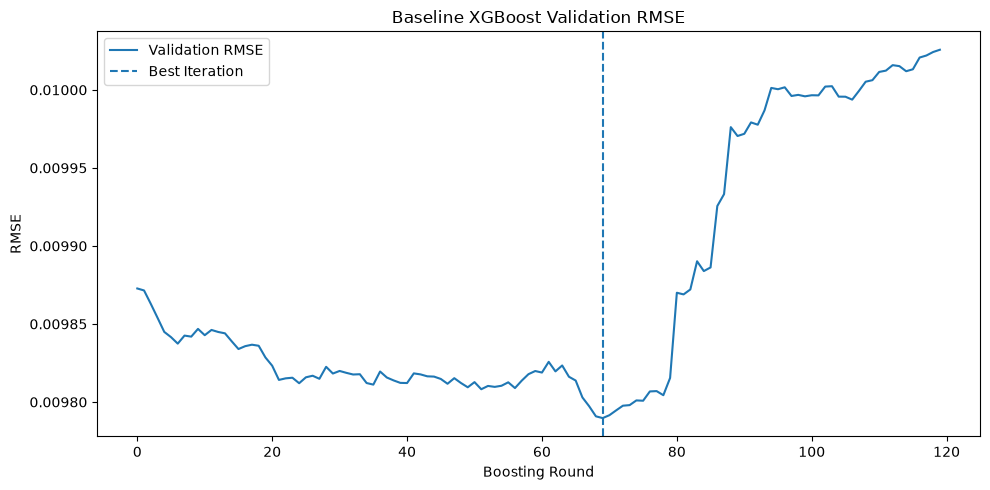

In [41]:
evals_result = baseline_xgboost.evals_result()
validation_rmse = evals_result["validation_0"]["rmse"]

plt.figure(figsize=(10, 5))

plt.plot(validation_rmse, label="Validation RMSE")
plt.axvline(
    baseline_xgboost.best_iteration,
    linestyle="--",
    label="Best Iteration"
)

plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("Baseline XGBoost Validation RMSE")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

### 7.1 Tuning Strategy

A randomized search evaluates 50 unique hyperparameter configurations using expanding-window time-series cross-validation on the training set only. Each configuration is scored by its mean RMSE across 5 chronological folds. The validation set remains available for feature-set selection, and the test set remains untouched until the final model is selected.

### 7.2 Define Candidate Hyperparameter Space

In [42]:
tuning_space = {
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 10, 20, 50],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
    "n_estimators": [100, 200, 300, 500, 800],
    "subsample": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0.0, 0.1, 0.3, 0.5, 1.0, 2.0],
    "reg_alpha": [0.0, 0.001, 0.01, 0.1, 1.0, 5.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0, 20.0],
}

N_TUNING_CONFIGS = 50
N_SPLITS = 5

rng = random.Random(SEED)
tuning_configs = []
seen_configs = set()

while len(tuning_configs) < N_TUNING_CONFIGS:
    config = {
        name: rng.choice(values)
        for name, values in tuning_space.items()
    }

    signature = tuple(
        (name, config[name])
        for name in sorted(config)
    )

    if signature not in seen_configs:
        seen_configs.add(signature)
        tuning_configs.append(config)

print("Number of candidate configurations:", len(tuning_configs))

Number of candidate configurations: 50


### 7.3 Run Time-Series Cross-Validation

In [43]:
splitter = TimeSeriesSplit(n_splits=N_SPLITS)
tuning_results = []

for config_id, config in enumerate(tuning_configs, start=1):
    fold_rmses = []

    for train_index, validation_index in splitter.split(X_train):
        fold_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
            **config,
        )

        fold_model.fit(
            X_train.iloc[train_index],
            y_train.iloc[train_index],
            verbose=False,
        )

        fold_predictions = fold_model.predict(
            X_train.iloc[validation_index]
        )

        fold_rmse = np.sqrt(
            mean_squared_error(
                y_train.iloc[validation_index],
                fold_predictions,
            )
        )

        fold_rmses.append(fold_rmse)

    tuning_results.append({
        "Config_ID": config_id,
        **config,
        "Mean_CV_RMSE": np.mean(fold_rmses),
        "Std_CV_RMSE": np.std(fold_rmses),
    })

tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values(
    by=["Mean_CV_RMSE", "Std_CV_RMSE"]
).reset_index(drop=True)

tuning_results_df.head(10)

,Config_ID,max_depth,min_child_weight,learning_rate,n_estimators,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,Mean_CV_RMSE,Std_CV_RMSE
0,5,4,5,0.010,200,0.7,0.5,0.0,0.100,0.5,0.011237,0.002614
1,30,2,1,0.030,300,0.5,0.6,0.1,0.001,10.0,0.011242,0.002578
2,46,4,20,0.030,300,0.5,0.5,2.0,0.100,2.0,0.011242,0.002578
3,37,3,1,0.050,100,0.6,0.5,1.0,0.000,20.0,0.011243,0.002578
4,12,4,10,0.020,100,0.6,0.9,2.0,0.010,1.0,0.011243,0.002578
5,26,2,50,0.005,200,0.5,0.5,0.3,0.000,10.0,0.011244,0.002578
6,15,6,10,0.005,100,0.5,0.6,2.0,0.001,20.0,0.011244,0.002578
7,32,6,1,0.005,800,0.5,0.5,0.1,0.001,5.0,0.011244,0.002578
8,23,6,20,0.030,200,0.9,1.0,2.0,0.001,20.0,0.011244,0.002578
9,33,5,10,0.010,500,0.5,0.6,0.5,0.000,5.0,0.011244,0.002578


### 7.4 Select Best Configuration

In [44]:
best_row = tuning_results_df.loc[0]

parameter_names = list(tuning_space.keys())
best_config = {
    parameter: best_row[parameter]
    for parameter in parameter_names
}

for integer_parameter in ["max_depth", "min_child_weight", "n_estimators"]:
    best_config[integer_parameter] = int(best_config[integer_parameter])

print("Best configuration:")
for parameter, value in best_config.items():
    print(f"- {parameter}: {value}")

print("\nBest mean CV RMSE:", best_row["Mean_CV_RMSE"])

Best configuration:
- max_depth: 4
- min_child_weight: 5
- learning_rate: 0.01
- n_estimators: 200
- subsample: 0.7
- colsample_bytree: 0.5
- gamma: 0.0
- reg_alpha: 0.1
- reg_lambda: 0.5

Best mean CV RMSE: 0.011236755385275117


## 8. Feature Importance and Feature Selection

### 8.1 Fit Tuned Model on Training Data

In [45]:
tuned_training_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
    **best_config,
)

tuned_training_model.fit(
    X_train,
    y_train,
    verbose=False,
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,np.float64(0.5)
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


The tuned model used for feature ranking is fit on the training set only, so the feature importance order does not use validation or test outcomes.

### 8.2 Feature Importance Table

In [46]:
xgboost_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tuned_training_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

xgboost_feature_importance["Rank"] = np.arange(
    1, len(xgboost_feature_importance) + 1
)

xgboost_feature_importance

,Feature,Importance,Rank
0,us_2_year_treasury_yields_diff_bps,0.076549,1
1,us_dollar_index_return_1d,0.066609,2
2,gold_return_20d,0.061538,3
3,breakeven_inflation_10y_diff_bps,0.057985,4
4,gold_volatility_20d,0.056625,5
5,gold_close_pos,0.050054,6
6,us_10_year_treasury_yields_diff_bps,0.048572,7
7,sp_500_return_1d,0.047775,8
8,gold_relative_volume,0.047307,9
9,silver_return_1d,0.046249,10


### 8.3 Feature Importance Plot

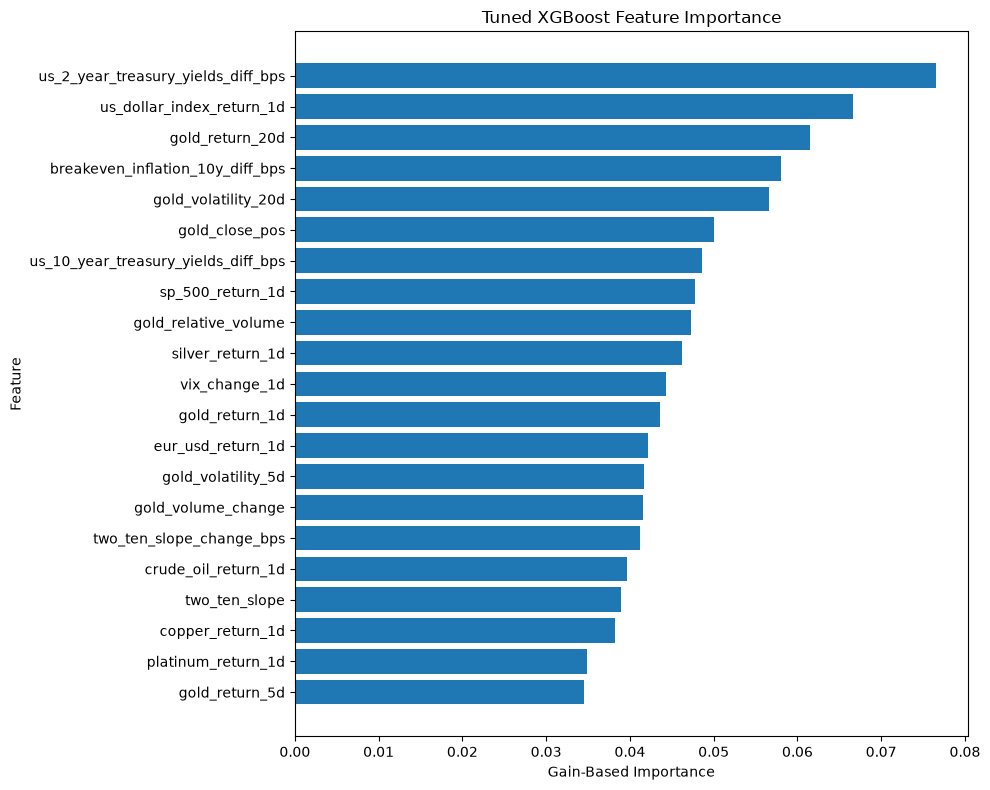

In [47]:
plt.figure(figsize=(10, 8))

plt.barh(
    xgboost_feature_importance["Feature"],
    xgboost_feature_importance["Importance"]
)

plt.xlabel("Gain-Based Importance")
plt.ylabel("Feature")
plt.title("Tuned XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 8.4 Feature-Set Comparison on Validation Data

Three feature sets are compared on the validation set: all 21 predictors, the top 10 most important features, and the top 5 most important features. Feature rankings are learned from the training set only, so the validation set can be used to select the final feature set without touching the test set.

In [48]:
ranked_features = xgboost_feature_importance["Feature"].tolist()

feature_sets = {
    "All Features": ranked_features,
    "Top 10 Features": ranked_features[:10],
    "Top 5 Features": ranked_features[:5],
}

feature_set_results = []

for feature_set_name, selected_feature_columns in feature_sets.items():
    feature_set_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED,
        **best_config,
    )

    feature_set_model.fit(
        X_train[selected_feature_columns],
        y_train,
        verbose=False,
    )

    feature_set_predictions = feature_set_model.predict(
        X_validation[selected_feature_columns]
    )

    feature_set_mae = mean_absolute_error(
        y_validation, feature_set_predictions
    )
    feature_set_mse = mean_squared_error(
        y_validation, feature_set_predictions
    )
    feature_set_rmse = np.sqrt(feature_set_mse)
    feature_set_r2 = r2_score(
        y_validation, feature_set_predictions
    )

    feature_set_directional_accuracy = np.mean(
        np.sign(feature_set_predictions)
        == np.sign(y_validation.to_numpy())
    )

    feature_set_results.append({
        "Feature_Set": feature_set_name,
        "Number_of_Features": len(selected_feature_columns),
        "Selected_Features": "|".join(selected_feature_columns),
        "MAE": feature_set_mae,
        "MSE": feature_set_mse,
        "RMSE": feature_set_rmse,
        "R2": feature_set_r2,
        "Directional_Accuracy": feature_set_directional_accuracy,
    })

feature_set_comparison = pd.DataFrame(
    feature_set_results
).sort_values(
    by=["RMSE", "MAE"]
).reset_index(drop=True)

feature_set_comparison

,Feature_Set,Number_of_Features,Selected_Features,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Top 10 Features,10,us_2_year_treasury_yields_diff_bps|us_dollar_i...,0.007165,0.000096,0.009802,0.014594,0.527926
1,All Features,21,us_2_year_treasury_yields_diff_bps|us_dollar_i...,0.007150,0.000096,0.009803,0.014418,0.523936
2,Top 5 Features,5,us_2_year_treasury_yields_diff_bps|us_dollar_i...,0.007194,0.000097,0.009869,0.001212,0.514628


### 8.5 Feature-Set Comparison Plot

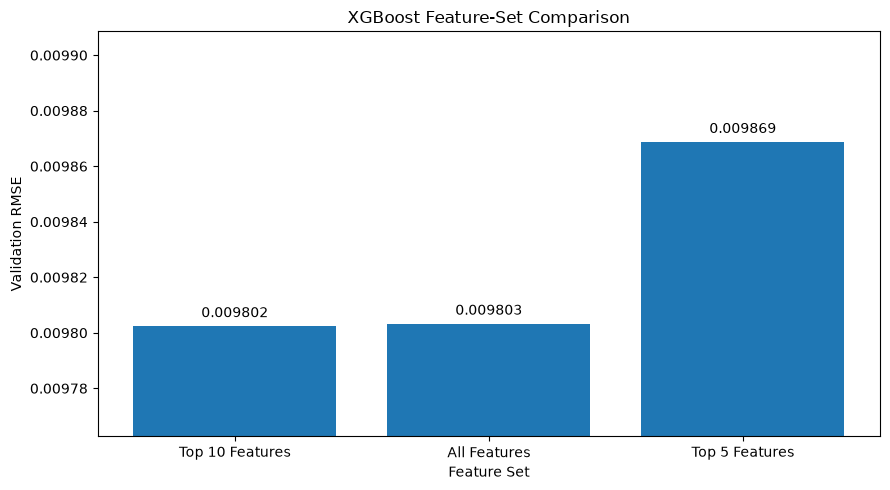

In [49]:
rmse_values = feature_set_comparison["RMSE"]
rmse_range = rmse_values.max() - rmse_values.min()
padding = rmse_range * 0.6 if rmse_range > 0 else rmse_values.min() * 0.01

plt.figure(figsize=(9, 5))

bars = plt.bar(
    feature_set_comparison["Feature_Set"],
    rmse_values
)

for bar, value in zip(bars, rmse_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + padding * 0.05,
        f"{value:.6f}",
        ha="center",
        va="bottom"
    )

plt.ylim(rmse_values.min() - padding, rmse_values.max() + padding)
plt.xlabel("Feature Set")
plt.ylabel("Validation RMSE")
plt.title("XGBoost Feature-Set Comparison")
plt.tight_layout()
plt.show()

### 8.6 Select Final Feature Set

In [50]:
selected_feature_set_name = feature_set_comparison.loc[0, "Feature_Set"]
selected_features = feature_set_comparison.loc[0, "Selected_Features"].split("|")

print("Selected feature set:", selected_feature_set_name)
print("Selected feature count:", len(selected_features))
print("\nSelected features:")
for feature in selected_features:
    print("-", feature)

Selected feature set: Top 10 Features
Selected feature count: 10

Selected features:
- us_2_year_treasury_yields_diff_bps
- us_dollar_index_return_1d
- gold_return_20d
- breakeven_inflation_10y_diff_bps
- gold_volatility_20d
- gold_close_pos
- us_10_year_treasury_yields_diff_bps
- sp_500_return_1d
- gold_relative_volume
- silver_return_1d


Tuning and feature-set comparison on the validation set selected the Top 10 Features set, though the differences between feature sets were extremely small: validation RMSE was 0.009802 for the top 10 features, 0.009803 for all 21 features, and 0.009869 for the top 5 features. Dropping from 21 to 10 predictors cost essentially nothing in validation accuracy, while dropping to 5 features degraded performance slightly.

The ten retained features were led by the change in the 2-year U.S. Treasury yield and the 1-day U.S. dollar index return, followed by the 20-day gold return, the change in 10-year breakeven inflation, 20-day gold volatility, gold's closing position, the change in the 10-year Treasury yield, the S&P 500 return, gold's relative trading volume, and the silver return. This is broadly consistent with the Lasso feature selection, where interest-rate, inflation, and dollar-strength predictors were also the most influential.

## 9. Tuned XGBoost Evaluation

In [51]:
X_dev = pd.concat([X_train, X_validation])
y_dev = pd.concat([y_train, y_validation])

tuned_xgboost = xgb.XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEED,
    **best_config,
)

tuned_xgboost.fit(
    X_dev[selected_features],
    y_dev,
    verbose=False,
)

tuned_test_predictions = tuned_xgboost.predict(
    X_test[selected_features]
)

tuned_mae = mean_absolute_error(y_test, tuned_test_predictions)
tuned_mse = mean_squared_error(y_test, tuned_test_predictions)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, tuned_test_predictions)

tuned_directional_accuracy = np.mean(
    np.sign(tuned_test_predictions)
    == np.sign(y_test.to_numpy())
)

tuned_xgboost_metrics = pd.DataFrame({
    "Model": ["Tuned XGBoost"],
    "MAE": [tuned_mae],
    "MSE": [tuned_mse],
    "RMSE": [tuned_rmse],
    "R2": [tuned_r2],
    "Directional_Accuracy": [tuned_directional_accuracy]
})

xgboost_test_comparison = pd.concat(
    [zero_baseline_metrics, baseline_xgboost_metrics, tuned_xgboost_metrics],
    ignore_index=True
)

xgboost_test_comparison

,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN
1,Baseline XGBoost,0.009201,0.000174,0.013206,-0.000923,0.541833
2,Tuned XGBoost,0.009191,0.000175,0.013233,-0.005104,0.527224


On the test set:

| Model | MAE | MSE | RMSE | R² | Directional Accuracy |
|---|---|---|---|---|---|
| Zero-Return Baseline | 0.009195 | 0.000175 | 0.013236 | -0.005592 | — |
| Baseline XGBoost | 0.009201 | 0.000174 | 0.013206 | -0.000923 | 54.18% |
| Tuned XGBoost | 0.009191 | 0.000175 | 0.013233 | -0.005104 | 52.72% |

Tuning and feature selection, both chosen using validation-set RMSE, did not translate into an improvement on the held-out test set. The tuned model's RMSE and R² are essentially indistinguishable from the zero-return baseline, and slightly worse than the untuned baseline XGBoost model on every metric except MAE. Directional accuracy also fell from 54.18% (baseline) to 52.72% (tuned).

This suggests the training-set time-series cross-validation and the validation-set feature-set comparison picked up noise rather than a signal that generalizes to the test period, and that, similar to the Lasso model, the available predictors carry very little linear or tree-based signal about the magnitude of next-day gold returns.

## 10. Prediction and Residual Diagnostics

### 10.1 Actual Versus Tuned XGBoost Predictions

In [52]:
xgboost_test_predictions = pd.DataFrame({
    "Date": y_test.index,
    "Actual_Return": y_test.to_numpy(),
    "Baseline_XGBoost_Prediction": baseline_test_predictions,
    "Tuned_XGBoost_Prediction": tuned_test_predictions
})

xgboost_test_predictions.head()

,Date,Actual_Return,Baseline_XGBoost_Prediction,Tuned_XGBoost_Prediction
0,2023-07-11,0.012810,0.002510,0.000170
1,2023-07-12,0.001532,0.004011,0.002182
2,2023-07-13,0.000459,0.002438,0.001953
3,2023-07-14,-0.003936,-0.000437,-0.001306
4,2023-07-17,0.012622,0.001333,0.000492


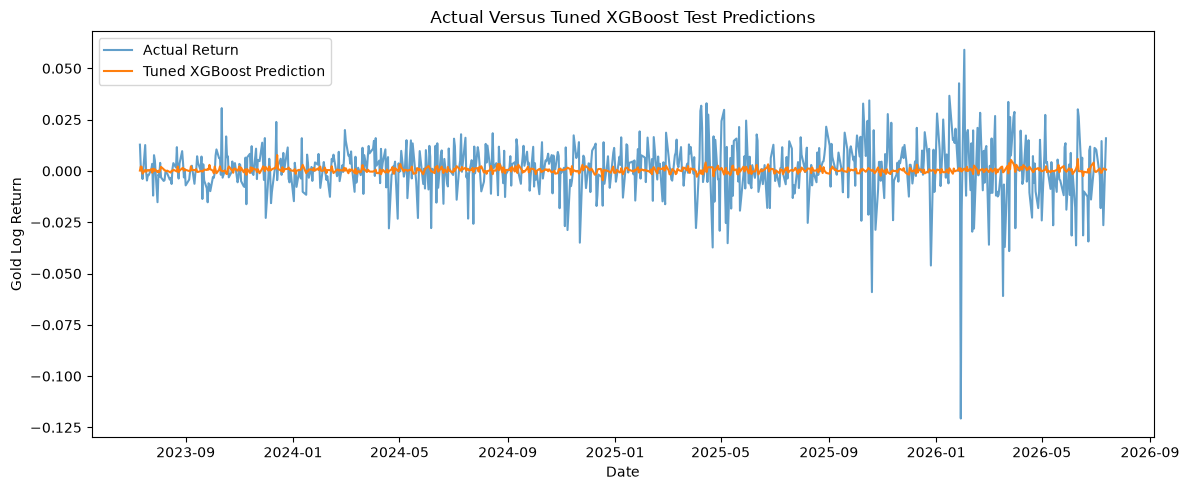

In [53]:
plt.figure(figsize=(12, 5))

plt.plot(
    xgboost_test_predictions["Date"],
    xgboost_test_predictions["Actual_Return"],
    label="Actual Return",
    alpha=0.7
)

plt.plot(
    xgboost_test_predictions["Date"],
    xgboost_test_predictions["Tuned_XGBoost_Prediction"],
    label="Tuned XGBoost Prediction"
)

plt.xlabel("Date")
plt.ylabel("Gold Log Return")
plt.title("Actual Versus Tuned XGBoost Test Predictions")
plt.legend()
plt.tight_layout()
plt.show()

### 10.2 Residual Analysis

In [54]:
xgboost_residuals = (
    xgboost_test_predictions["Actual_Return"]
    - xgboost_test_predictions["Tuned_XGBoost_Prediction"]
)

residual_summary = pd.DataFrame({
    "Actual_Return": xgboost_test_predictions["Actual_Return"],
    "Predicted_Return": xgboost_test_predictions["Tuned_XGBoost_Prediction"],
    "Residual": xgboost_residuals
})

residual_summary.describe()

,Actual_Return,Predicted_Return,Residual
count,753.000000,753.000000,753.000000
mean,0.000987,0.000418,0.000569
std,0.013208,0.001165,0.013230
min,-0.120657,-0.004534,-0.121883
25%,-0.004733,-0.000274,-0.005246
50%,0.001489,0.000356,0.001058
75%,0.007958,0.001043,0.007911
max,0.059054,0.007744,0.057903


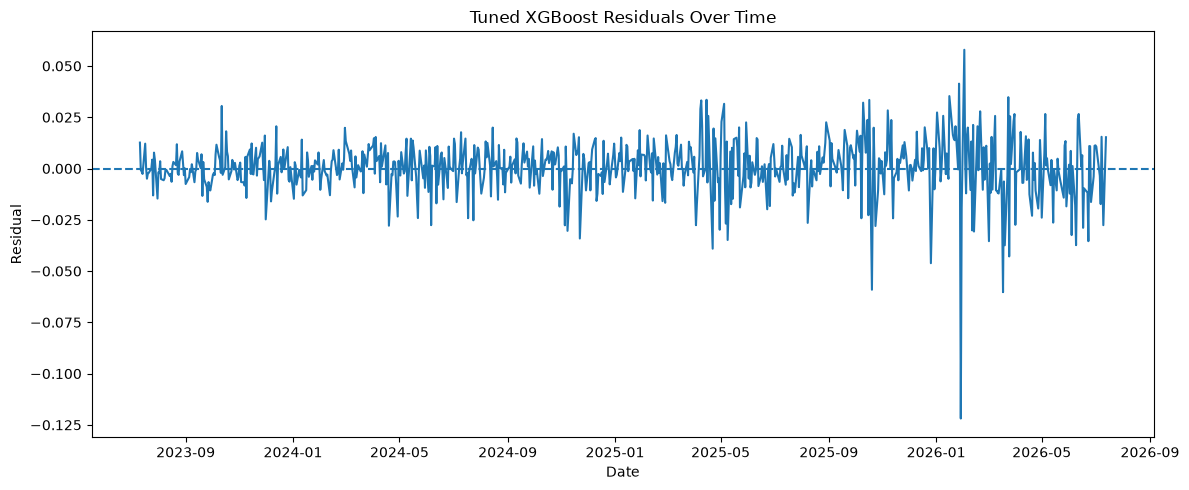

In [55]:
plt.figure(figsize=(12, 5))

plt.plot(
    xgboost_test_predictions["Date"],
    xgboost_residuals
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Tuned XGBoost Residuals Over Time")
plt.tight_layout()
plt.show()

The residuals oscillate closely around zero for most of the test period, but several sharp spikes appear during unusually volatile stretches — most notably a residual of roughly -0.12 in early 2026, coinciding with a large actual gold return that the model, like the Lasso model, failed to anticipate. This pattern mirrors the slightly negative R²: the model tracks ordinary day-to-day movements reasonably well but consistently underestimates the size of extreme moves.

## 11. Results

In [56]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [57]:
xgboost_metrics_path = RESULTS_DIR / "xgboost_metrics.csv"

xgboost_test_comparison.to_csv(
    xgboost_metrics_path,
    index=False
)

print(f"Saved metrics to: {xgboost_metrics_path}")
xgboost_test_comparison

Saved metrics to: results\xgboost_metrics.csv


,Model,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.009195,0.000175,0.013236,-0.005592,NaN
1,Baseline XGBoost,0.009201,0.000174,0.013206,-0.000923,0.541833
2,Tuned XGBoost,0.009191,0.000175,0.013233,-0.005104,0.527224


In [58]:
xgboost_predictions_path = RESULTS_DIR / "xgboost_predictions.csv"

xgboost_test_predictions.to_csv(
    xgboost_predictions_path,
    index=False
)

print(f"Saved predictions to: {xgboost_predictions_path}")
xgboost_test_predictions.head()

Saved predictions to: results\xgboost_predictions.csv


,Date,Actual_Return,Baseline_XGBoost_Prediction,Tuned_XGBoost_Prediction
0,2023-07-11,0.012810,0.002510,0.000170
1,2023-07-12,0.001532,0.004011,0.002182
2,2023-07-13,0.000459,0.002438,0.001953
3,2023-07-14,-0.003936,-0.000437,-0.001306
4,2023-07-17,0.012622,0.001333,0.000492


In [59]:
xgboost_tuning_results_path = RESULTS_DIR / "xgboost_tuning_results.csv"

tuning_results_df.to_csv(
    xgboost_tuning_results_path,
    index=False
)

print(f"Saved tuning results to: {xgboost_tuning_results_path}")
tuning_results_df.head()

Saved tuning results to: results\xgboost_tuning_results.csv


,Config_ID,max_depth,min_child_weight,learning_rate,n_estimators,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,Mean_CV_RMSE,Std_CV_RMSE
0,5,4,5,0.01,200,0.7,0.5,0.0,0.100,0.5,0.011237,0.002614
1,30,2,1,0.03,300,0.5,0.6,0.1,0.001,10.0,0.011242,0.002578
2,46,4,20,0.03,300,0.5,0.5,2.0,0.100,2.0,0.011242,0.002578
3,37,3,1,0.05,100,0.6,0.5,1.0,0.000,20.0,0.011243,0.002578
4,12,4,10,0.02,100,0.6,0.9,2.0,0.010,1.0,0.011243,0.002578


In [60]:
xgboost_feature_importance_path = (
    RESULTS_DIR / "xgboost_feature_importance.csv"
)

xgboost_feature_importance.to_csv(
    xgboost_feature_importance_path,
    index=False
)

print(
    "Saved feature importance to:",
    xgboost_feature_importance_path
)

xgboost_feature_importance.head()

Saved feature importance to: results\xgboost_feature_importance.csv


,Feature,Importance,Rank
0,us_2_year_treasury_yields_diff_bps,0.076549,1
1,us_dollar_index_return_1d,0.066609,2
2,gold_return_20d,0.061538,3
3,breakeven_inflation_10y_diff_bps,0.057985,4
4,gold_volatility_20d,0.056625,5


In [61]:
xgboost_feature_set_comparison_path = (
    RESULTS_DIR / "xgboost_feature_set_comparison.csv"
)

feature_set_comparison.to_csv(
    xgboost_feature_set_comparison_path,
    index=False
)

print(
    "Saved feature-set comparison to:",
    xgboost_feature_set_comparison_path
)

feature_set_comparison

Saved feature-set comparison to: results\xgboost_feature_set_comparison.csv


,Feature_Set,Number_of_Features,Selected_Features,MAE,MSE,RMSE,R2,Directional_Accuracy
0,Top 10 Features,10,us_2_year_treasury_yields_diff_bps|us_dollar_i...,0.007165,0.000096,0.009802,0.014594,0.527926
1,All Features,21,us_2_year_treasury_yields_diff_bps|us_dollar_i...,0.007150,0.000096,0.009803,0.014418,0.523936
2,Top 5 Features,5,us_2_year_treasury_yields_diff_bps|us_dollar_i...,0.007194,0.000097,0.009869,0.001212,0.514628


In [62]:
xgboost_selected_features = pd.DataFrame({
    "Feature_Set": [selected_feature_set_name] * len(selected_features),
    "Feature": selected_features
})

xgboost_selected_features_path = (
    RESULTS_DIR / "xgboost_selected_features.csv"
)

xgboost_selected_features.to_csv(
    xgboost_selected_features_path,
    index=False
)

print(
    "Saved selected features to:",
    xgboost_selected_features_path
)

xgboost_selected_features

Saved selected features to: results\xgboost_selected_features.csv


,Feature_Set,Feature
0,Top 10 Features,us_2_year_treasury_yields_diff_bps
1,Top 10 Features,us_dollar_index_return_1d
2,Top 10 Features,gold_return_20d
3,Top 10 Features,breakeven_inflation_10y_diff_bps
4,Top 10 Features,gold_volatility_20d
5,Top 10 Features,gold_close_pos
6,Top 10 Features,us_10_year_treasury_yields_diff_bps
7,Top 10 Features,sp_500_return_1d
8,Top 10 Features,gold_relative_volume
9,Top 10 Features,silver_return_1d


In [63]:
xgboost_best_configuration = pd.DataFrame([{
    **best_config,
    "Selected_Feature_Set": selected_feature_set_name,
    "Selected_Feature_Count": len(selected_features),
}])

xgboost_best_configuration_path = (
    RESULTS_DIR / "xgboost_best_configuration.csv"
)

xgboost_best_configuration.to_csv(
    xgboost_best_configuration_path,
    index=False
)

print(
    "Saved best configuration to:",
    xgboost_best_configuration_path
)

xgboost_best_configuration

Saved best configuration to: results\xgboost_best_configuration.csv


,max_depth,min_child_weight,learning_rate,n_estimators,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,Selected_Feature_Set,Selected_Feature_Count
0,4,5,0.01,200,0.7,0.5,0.0,0.1,0.5,Top 10 Features,10


## 12. Conclusion

The XGBoost model was trained to predict the next trading day's gold log return using the same 21 commodity, financial-market, and macroeconomic predictors used in the Lasso and LSTM notebooks.

The baseline XGBoost model used early stopping against the chronological validation set and barely outperformed the zero-return baseline (test RMSE 0.013206 vs. 0.013236). A randomized search over 50 hyperparameter configurations, evaluated with expanding-window time-series cross-validation on the training set, selected a configuration with max_depth=4, learning_rate=0.01, n_estimators=200, subsample=0.7, colsample_bytree=0.5, reg_alpha=0.1, and reg_lambda=0.5. A feature-set comparison on the validation set then selected the Top 10 Features (led by the 2-year Treasury yield change and the U.S. dollar index return), although the top 10, top 5, and full 21-feature sets performed almost identically.

On the test set, the tuned XGBoost model achieved:

- MAE: 0.009191
- MSE: 0.000175
- RMSE: 0.013233
- R²: -0.005104
- Directional accuracy: 52.72%

These figures are essentially tied with the zero-return baseline and slightly worse than the untuned baseline XGBoost model (RMSE 0.013206, R² -0.000923, directional accuracy 54.18%) on every metric except MAE. Hyperparameter tuning and feature selection, both chosen via validation-set performance, did not generalize to an improvement on the test set.

The most influential predictors were changes in the 2-year U.S. Treasury yield and the U.S. dollar index return, followed by the 20-day gold return, 10-year breakeven inflation changes, and 20-day gold volatility — a set of features broadly consistent with what Lasso identified as important.

Overall, like the Lasso model, XGBoost was unable to meaningfully outperform a naive zero-return baseline on this dataset. Predictions stayed compressed near zero and underestimated the magnitude of large market moves, and R² remained slightly negative on the test set. This reinforces the conclusion that the available daily predictors contain very little information — linear or nonlinear — about the size of next-day gold returns, particularly during volatile periods.